In [832]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

from time import time
from datetime import timedelta

from sklearn.model_selection import train_test_split,  KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,GradientBoostingClassifier,StackingClassifier,ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB, CategoricalNB
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

from sklearn.metrics import confusion_matrix, \
                  classification_report, accuracy_score,  precision_score, recall_score, f1_score

from IPython.core.interactiveshell import InteractiveShell

pd.set_option('display.precision', 3)

In [833]:
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123) # for reproducibility

## Suporting function

In [834]:
def confusion(true, pred):
    """
    Function for pretty printing confusion matrices
    """
    #true.name = 'target'
    #pred.name = 'predicted'
    cm = pd.crosstab(true.reset_index(drop=True), pred.reset_index(drop=True))
    cm = cm[cm.index]
    return cm

***
## Classification on Liver Data

In [835]:
train_liver = pd.read_pickle('train_liver_processed.pkl.bz2',compression='bz2')
test_liver = pd.read_pickle('test_liver_processed.pkl.bz2',compression='bz2')

In [836]:
train_liver.head()

,Age,Gender,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/R,Label
0,0.709,Female,0.210,0.082,0.008,6.814e-04,0.382,0.370,0.24,1
1,0.616,Male,0.265,0.118,0.015,2.555e-02,0.559,0.348,0.12,0
2,0.512,Female,0.373,0.291,0.084,8.143e-02,0.779,0.717,0.32,0
3,0.314,Male,0.132,0.285,0.090,2.044e-03,0.382,0.304,0.16,0
4,0.593,Male,0.132,0.262,0.051,2.998e-02,0.441,0.370,0.20,0


In [837]:
test_liver.describe()

,Age,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/R
count,116.000,116.000,116.000,1.160e+02,1.160e+02,116.000,116.000,116.000
mean,0.470,0.326,0.169,4.634e-02,5.129e-02,0.591,0.511,0.265
std,0.185,0.263,0.219,1.156e-01,1.663e-01,0.174,0.172,0.130
min,0.081,0.000,-0.008,5.025e-04,-3.407e-04,0.015,0.109,0.000
25%,0.334,0.132,0.064,7.412e-03,6.048e-03,0.485,0.413,0.200
50%,0.442,0.210,0.089,1.432e-02,1.124e-02,0.618,0.500,0.280
75%,0.628,0.492,0.186,3.216e-02,3.203e-02,0.706,0.652,0.320
max,0.826,1.014,1.309,8.392e-01,1.676e+00,1.015,0.870,0.880


In [838]:
test_liver

,Age,Gender,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/R
0,0.081,Male,0.000,0.332,0.008,0.006,0.647,0.717,0.440
1,0.674,Male,0.421,0.096,0.030,0.049,0.868,0.674,0.200
2,0.651,Male,0.132,0.064,0.011,0.001,0.750,0.717,0.320
3,0.651,Male,0.639,0.089,0.202,0.286,0.676,0.500,0.192
4,0.512,Female,0.132,0.064,0.007,0.015,0.412,0.391,0.240
...,...,...,...,...,...,...,...,...,...
111,0.756,Female,0.132,0.046,0.016,0.020,0.838,0.870,0.440
112,0.360,Male,0.920,0.021,0.079,0.211,0.956,0.239,0.000
113,0.442,Male,0.132,0.025,0.006,0.004,0.632,0.457,0.160
114,0.163,Male,0.132,0.298,0.012,0.008,0.706,0.500,0.160


In [839]:
numerical_cols = ['Age', 'DB', 'Alkphos','Sgpt', 'Sgot', 'TP', 'ALB', 'A/R' ]

categorical_cols = ['Gender']

In [840]:
X = train_liver.loc[:,train_liver.columns != 'Label']
y = train_liver['Label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

### Preprocessing

In [841]:
def preprocessing(X, y):        
    # We apply one-hot-encoding to the categorical columns 
    for column in X.columns:
        if X[column].dtype.kind == 'O':
            X_one_hot = pd.get_dummies(X[column], prefix=column)
            X = X.merge(X_one_hot,left_index=True,right_index=True)
            X = X.drop(columns=[column])
    return X, y

X_train, y_train = preprocessing(X_train, y_train)
X_val, y_val = preprocessing(X_val, y_val)
X_test, _ = preprocessing(test_liver, None)

In [842]:
X_train.head()

,Age,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/R,Gender_Male,Gender_Female
181,0.512,0.210,0.151,0.014,0.015,0.471,0.348,0.16,False,True
414,0.477,0.476,0.057,0.009,0.004,0.721,0.674,0.32,True,False
141,0.628,0.000,0.016,0.025,0.039,0.235,0.348,0.44,True,False
338,0.651,0.398,0.347,0.016,0.009,0.265,0.196,0.12,True,False
244,0.535,0.265,0.133,0.013,0.007,0.662,0.652,0.32,True,False


### Ensemble methods

In [843]:
def compute_metrics(y_true,y_pred):
    f1_score_1 = f1_score(y_true,y_pred,average='binary',pos_label=1)
    f1_score_0 = f1_score(y_true,y_pred,average='binary',pos_label=0)
    f1_score_macro = f1_score(y_true,y_pred,average='macro')
    return [f1_score_1,f1_score_0,f1_score_macro]

### Random forest

In [844]:
from sklearn.metrics import make_scorer

results = pd.DataFrame(columns=['F1-score (class 1)', 'F1-score (class 0)', 'F1-score (macro avg)'])

f1_class_0_scorer = make_scorer(f1_score, pos_label=0)
f1_class_1_scorer = make_scorer(f1_score, pos_label=1)

scoring_dict = {
    'f1_mac': 'f1_macro',
    'f1_class_0': f1_class_0_scorer,
    'f1_class_1': f1_class_1_scorer
}

In [845]:
model_rf1 = RandomForestClassifier(oob_score=True).fit(X_train, y_train)

pred = model_rf1.predict(X_train)

print(confusion_matrix(y_train,pred))

print(classification_report(y_train, pred, target_names=['no', 'yes'],))

print('OOB accuracy=', model_rf1.oob_score_)

[[221   0]
 [  0  89]]
              precision    recall  f1-score   support

          no       1.00      1.00      1.00       221
         yes       1.00      1.00      1.00        89

    accuracy                           1.00       310
   macro avg       1.00      1.00      1.00       310
weighted avg       1.00      1.00      1.00       310

OOB accuracy= 0.6903225806451613


In [846]:
y_pred = model_rf1.predict(X_val)
print('Validation Accuracy:{}'.format(model_rf1.score(X_val,y_val)))
results.loc['RF-default',:] = compute_metrics(y_val,y_pred)
print(confusion_matrix(y_val,y_pred))

Validation Accuracy:0.7581699346405228
[[101   9]
 [ 28  15]]


In [847]:
results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
RF-default,0.448,0.845,0.646


In [848]:
model_rf2 = RandomForestClassifier(n_estimators=100, 
                                   oob_score=True, 
                                   class_weight='balanced').fit(X_train, y_train)

pred = model_rf2.predict(X_train)

print(confusion_matrix(y_train, pred))

print(classification_report(y_train,pred,target_names=['no', 'yes'],))

print('OOB accuracy=', model_rf2.oob_score_)

[[221   0]
 [  0  89]]
              precision    recall  f1-score   support

          no       1.00      1.00      1.00       221
         yes       1.00      1.00      1.00        89

    accuracy                           1.00       310
   macro avg       1.00      1.00      1.00       310
weighted avg       1.00      1.00      1.00       310

OOB accuracy= 0.6709677419354839


In [849]:
y_pred = model_rf2.predict(X_val)

results.loc['RF-balance',:] = compute_metrics(y_val,y_pred)

print(confusion_matrix(y_val,y_pred))

[[99 11]
 [28 15]]


In [850]:
results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635


In [851]:
init_time = time()

rf_model = RandomForestClassifier()

ntrees = [200,None]
max_depth = [100,None]
min_samples_split = [4,6]
min_samples_leaf = [4,6]
balance = [None, 'balanced', 'balanced_subsample']

trc = GridSearchCV(estimator=rf_model,
                   scoring=scoring_dict,
                   param_grid={
                       'n_estimators': ntrees,
                       'max_depth':max_depth,
                       'min_samples_split':min_samples_split,
                       'min_samples_leaf':min_samples_leaf, 
                       'class_weight':balance
                   },
                   cv=10,
                   return_train_score=False,
                   refit=False,
                   n_jobs=-1)

model_10CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

0:00:28.833962


In [852]:
best_params = pd.DataFrame(model_10CV.cv_results_).sort_values(by='mean_test_f1_mac',ascending=False)[['params']].iloc[0,0]
best_params

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 6,
 'min_samples_split': 4,
 'n_estimators': 200}

In [853]:
rf_model_tuned = RandomForestClassifier(**best_params)
rf_model_tuned.fit(X_train, y_train)

y_pred = rf_model_tuned.predict(X_val)

results.loc['RF-best', :] = compute_metrics(y_val, y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
RF-best,0.587,0.772,0.679
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635


In [854]:
print(confusion_matrix(y_val, y_pred))

[[76 34]
 [11 32]]


### Extra trees

In [855]:
extra_trees = ExtraTreesClassifier()
extra_trees.fit(X_train,y_train)

y_pred = extra_trees.predict(X_val)

results.loc['extra_trees',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
RF-best,0.587,0.772,0.679
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635


In [856]:
nit_time = time()

rf_model = ExtraTreesClassifier(class_weight='balanced')

ntrees = [150, None]
max_depth = [100, None]
min_samples_split = [4, 6]
min_samples_leaf = [2, 4]
balance = [None, 'balanced', 'balanced_subsample']

trc = GridSearchCV(estimator=rf_model,
                   scoring=scoring_dict,
                   param_grid={
                       'n_estimators': ntrees,
                       'max_depth': max_depth,
                       'min_samples_split': min_samples_split,
                       'min_samples_leaf': min_samples_leaf,
                       'class_weight': balance
                   },
                   cv=10,
                   return_train_score=True,
                   refit=False,
                   n_jobs=-1)

model_10CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

0:00:42.811176


In [857]:
best_params = pd.DataFrame(model_10CV.cv_results_).sort_values(by='mean_test_f1_mac',ascending=False)[['params']].iloc[0,0]
best_params

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 6,
 'n_estimators': 150}

In [858]:
extra_trees_best = ExtraTreesClassifier(**best_params)
extra_trees_best.fit(X_train,y_train)

y_pred = extra_trees_best.predict(X_val)

results.loc['extra_trees-best',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.615,0.762,0.689
RF-best,0.587,0.772,0.679
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635


## Feature importance

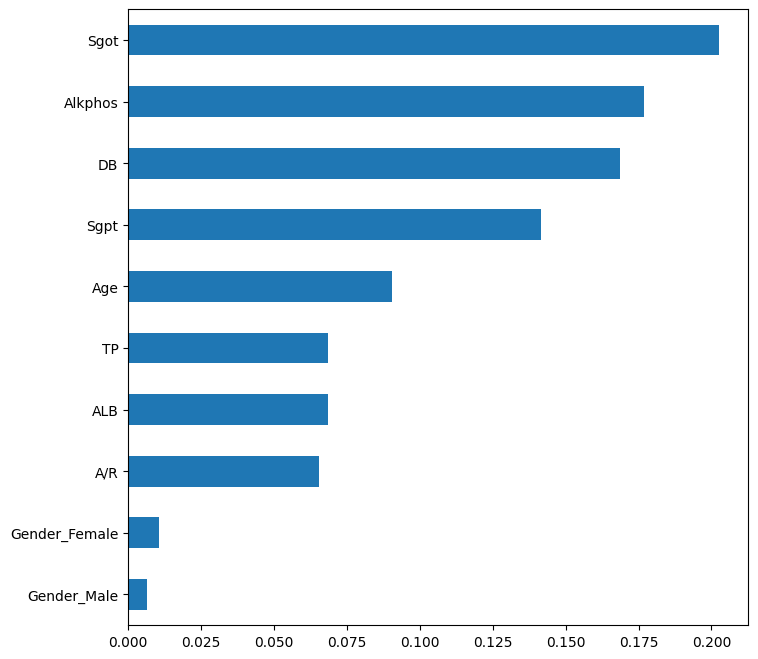

In [859]:
var_imp = pd.DataFrame({'importance': rf_model_tuned.feature_importances_},
                       index=X_train.columns)

var_imp.sort_values(by='importance').plot.barh(figsize=(8,8),
                                               legend=False);

## Gradient boosting

In [860]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score

# Definimos el modelo base
gbr = GradientBoostingClassifier()

# Definimos la cuadrícula de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Definimos el grid search con validación cruzada de 5 folds
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid,
                           scoring='accuracy', cv=10, n_jobs=-1, verbose=1)

# Entrenamos sobre el conjunto de entrenamiento
grid_search.fit(X_train, y_train)

# Mejor modelo
best_gbr = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Predecimos sobre el conjunto de validación
y_pred = best_gbr.predict(X_val)

# Guardamos métricas en tu tabla
results.loc['Gradient boosting (CV)', :] = compute_metrics(y_val, y_pred)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


## XGB

In [861]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, f1_score, accuracy_score
import pandas as pd

# Métricas personalizadas (priorizando Recall para la clase 0 - enfermos)
scoring = {
    'Recall': make_scorer(recall_score, pos_label=1),  # Enfermos
    'F1': make_scorer(f1_score, pos_label=1),
    'Accuracy': 'accuracy'
}

# Definimos el modelo base con peso para clases desbalanceadas
xgb = XGBClassifier(scale_pos_weight=331/132, random_state=42)

# Cuadrícula de hiperparámetros optimizada para XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9],
    'gamma': [0, 0.1]  # Regularización
}

# Grid Search con validación cruzada estratificada
grid_search = GridSearchCV(estimator=xgb, 
                          param_grid=param_grid,
                          scoring=scoring,
                          refit='Recall',  # Priorizamos Recall para clase 0
                          cv=10, 
                          n_jobs=-1, 
                          verbose=1)

# Entrenamiento (SOLO sobre datos de entrenamiento)
grid_search.fit(X_train, y_train)

# Mejor modelo y sus parámetros
best_xgb = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)

# Predicción y evaluación
y_pred = best_xgb.predict(X_val)

# Guardamos métricas en la tabla
results.loc['XGBoost (CV)', :] = compute_metrics(y_val, y_pred)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
Mejores parámetros: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


## Decision tree

In [862]:
from sklearn.tree import DecisionTreeClassifier

criterion = ['gini', 'entropy']

max_dephts = [None, 5, 10, 15, 20]
min_samples_split = [1, 2, 3, 4, 5]
min_samples_leaf = [1, 2, 3, 4, 5]
max_features = ['auto', 'sqrt', 'log2', None]

init_time = time()
model_tree = DecisionTreeClassifier()

f1_class_0_scorer = make_scorer(f1_score, pos_label=0)
f1_class_1_scorer = make_scorer(f1_score, pos_label=1)

scoring_dict = {
    'f1_mac': 'f1_macro',
    'f1_class_0': f1_class_0_scorer,
    'f1_class_1': f1_class_1_scorer,
    'acc': 'accuracy'
}

trc = GridSearchCV(estimator=model_tree,
                   scoring=scoring_dict,
                   param_grid={
                       'criterion': criterion,
                       'max_depth': max_dephts,
                       'min_samples_split': min_samples_split,
                       'min_samples_leaf': min_samples_leaf,
                       'max_features': max_features
                   },
                   cv=10,
                   return_train_score=False,
                   refit='f1_mac')

model_10CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))


0:01:41.656214


In [863]:
best_params = model_10CV.best_params_
best_params

{'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 5}

In [864]:
y_pred = model_10CV.predict(X_val)

results.loc['DT-best',:] = compute_metrics(y_val, y_pred)

confusion_matrix(y_val,y_pred)
results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.615,0.762,0.689
RF-best,0.587,0.772,0.679
XGBoost (CV),0.588,0.738,0.663
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635
DT-best,0.473,0.77,0.622
Gradient boosting (CV),0.0,0.837,0.418


## Ensembles

In [865]:
gauss_nb = GaussianNB()
gauss_nb.fit(X_train,y_train)

y_pred = gauss_nb.predict(X_val)

results.loc['GaussianNB-default',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.615,0.762,0.689
RF-best,0.587,0.772,0.679
XGBoost (CV),0.588,0.738,0.663
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
RF-balance,0.435,0.835,0.635
DT-best,0.473,0.77,0.622
GaussianNB-default,0.529,0.602,0.565
Gradient boosting (CV),0.0,0.837,0.418


In [866]:
voting_hard = VotingClassifier([('rf', model_rf1), ('xgb', xgb), ('gnb',gauss_nb), ('extratrees',extra_trees)])

voting_hard.fit(X_train, y_train)

y_pred = voting_hard.predict(X_val)

results.loc['voting_hard', :] = compute_metrics(y_val, y_pred)

results.loc[['GaussianNB-default','RF-default','extra_trees','voting_hard'],:].sort_values(
    by='F1-score (class 1)',ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
GaussianNB-default,0.529,0.602,0.565
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
voting_hard,0.444,0.829,0.637


In [867]:
voting_soft = VotingClassifier([('rf', model_rf1),('xgb', xgb), ('gnb',gauss_nb),
                                ('extratrees',extra_trees)],voting='soft')
voting_soft.fit(X_train, y_train)

y_pred = voting_soft.predict(X_val)

results.loc['voting_soft', :] = compute_metrics(y_val, y_pred)

results.loc[['GaussianNB-default','RF-default','extra_trees','voting_hard','voting_soft'],:].sort_values(
    by='F1-score (class 1)',ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
voting_soft,0.594,0.8,0.697
GaussianNB-default,0.529,0.602,0.565
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
voting_hard,0.444,0.829,0.637


In [868]:
voting_best = VotingClassifier([('rf', rf_model_tuned), ('xgb', best_xgb), ('gnb',gauss_nb),    
                                ('extratrees',extra_trees_best)],voting='soft')
voting_best.fit(X_train, y_train)

y_pred = voting_best.predict(X_val)

results.loc['voting_best', :] = compute_metrics(y_val, y_pred)

results.loc[['RF-best','extra_trees-best','voting_best'],:].sort_values(by='F1-score (class 1)',ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.615,0.762,0.689
RF-best,0.587,0.772,0.679
voting_best,0.574,0.689,0.631


## General results

In [869]:
results.sort_values(by='F1-score (class 1)',ascending=False)

,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.615,0.762,0.689
voting_soft,0.594,0.8,0.697
XGBoost (CV),0.588,0.738,0.663
RF-best,0.587,0.772,0.679
voting_best,0.574,0.689,0.631
GaussianNB-default,0.529,0.602,0.565
DT-best,0.473,0.77,0.622
extra_trees,0.457,0.839,0.648
RF-default,0.448,0.845,0.646
voting_hard,0.444,0.829,0.637


## Final model

In [870]:
X_test

,Age,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/R,Gender_Male,Gender_Female
0,0.081,0.000,0.332,0.008,0.006,0.647,0.717,0.440,True,False
1,0.674,0.421,0.096,0.030,0.049,0.868,0.674,0.200,True,False
2,0.651,0.132,0.064,0.011,0.001,0.750,0.717,0.320,True,False
3,0.651,0.639,0.089,0.202,0.286,0.676,0.500,0.192,True,False
4,0.512,0.132,0.064,0.007,0.015,0.412,0.391,0.240,False,True
...,...,...,...,...,...,...,...,...,...,...
111,0.756,0.132,0.046,0.016,0.020,0.838,0.870,0.440,False,True
112,0.360,0.920,0.021,0.079,0.211,0.956,0.239,0.000,True,False
113,0.442,0.132,0.025,0.006,0.004,0.632,0.457,0.160,True,False
114,0.163,0.132,0.298,0.012,0.008,0.706,0.500,0.160,True,False


In [875]:
y_pred = voting_soft.predict(X_test)

In [876]:
# 2. Generar IDs automáticamente (1, 2, 3, ...)
ids = np.arange(1, len(y_pred) + 1)  # o range(1, len(y_pred)+1)

# Crear DataFrame a partir de las predicciones
df_submission = pd.DataFrame({
    "ID": range(1, len(y_pred) + 1),
    "Label": y_pred
})

# Guardar en CSV con el nombre correcto de columna
df_submission.to_csv("submission_ens.csv", index=False)

In [877]:
print(y_pred)

[1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0
 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 1
 0 0 1 0 0]


In [878]:
# Contar el número de 1's
num_unos = np.sum(y_pred == 1)
print(num_unos) 

39
